# Barotropic Stirring: Visualization Guide

Visualizations for Isca barotropic stirring simulation output (T85 resolution).
All plots use real simulation data loaded from NetCDF files.

Data variables used:
- `ucomp`: Zonal (east-west) wind component
- `vcomp`: Meridional (north-south) wind component
- `vor`: Relative vorticity
- `stream`: Streamfunction
- `pv`: Potential vorticity

---
## Setup: Load Simulation Data

In [1]:
SIM_DIR = "../../output/barotropic_stirring-T85/simulations/0"

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

from ml.isca_dataset import fix_time_units

ds = xr.open_mfdataset(
    f"{SIM_DIR}/run*/atmos_daily.nc",
    combine="by_coords",
    data_vars="minimal",
    coords="minimal",
    compat="override",
    decode_times=False,
    preprocess=fix_time_units,
)
ds = xr.decode_cf(ds, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True), decode_timedelta=True)

lon = ds.lon.values
lat = ds.lat.values
lat_rad = np.deg2rad(lat)
cos_weights = np.cos(lat_rad).clip(0)

EARTH_RADIUS = 6.371e6  # m

def area_mean(field_2d):
    """Area-weighted global mean of a 2D (lat, lon) field."""
    w = cos_weights[:, None]
    return (field_2d * w).sum() / w.sum()

print(f"Loaded: {dict(ds.sizes)}")
print(f"Time steps: {len(ds.time)}")
print(f"Grid: {len(lat)} x {len(lon)}")

Loaded: {'time': 105, 'lat': 128, 'lon': 256, 'nv': 2, 'lonb': 257, 'latb': 129}
Time steps: 105
Grid: 128 x 256


---
## 1.1 Vorticity Evolution (Multi-Panel Snapshots)

Spatial distribution of relative vorticity $\zeta$ at multiple time steps.
Color = vorticity in $\text{s}^{-1}$ (red = cyclonic/positive, blue = anticyclonic/negative).
All panels share the same color scale (98th percentile robust scaling).

**What to look for:**
- Coherent vortex structures vs pixel noise
- Propagation direction between panels
- Growth or decay of eddies over time
- Eddy activity concentrated near the stirring latitude

/var/folders/4p/1s3ml81d7sx9zjdx06ttqs8r0000gp/T/ipykernel_51357/1079579912.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


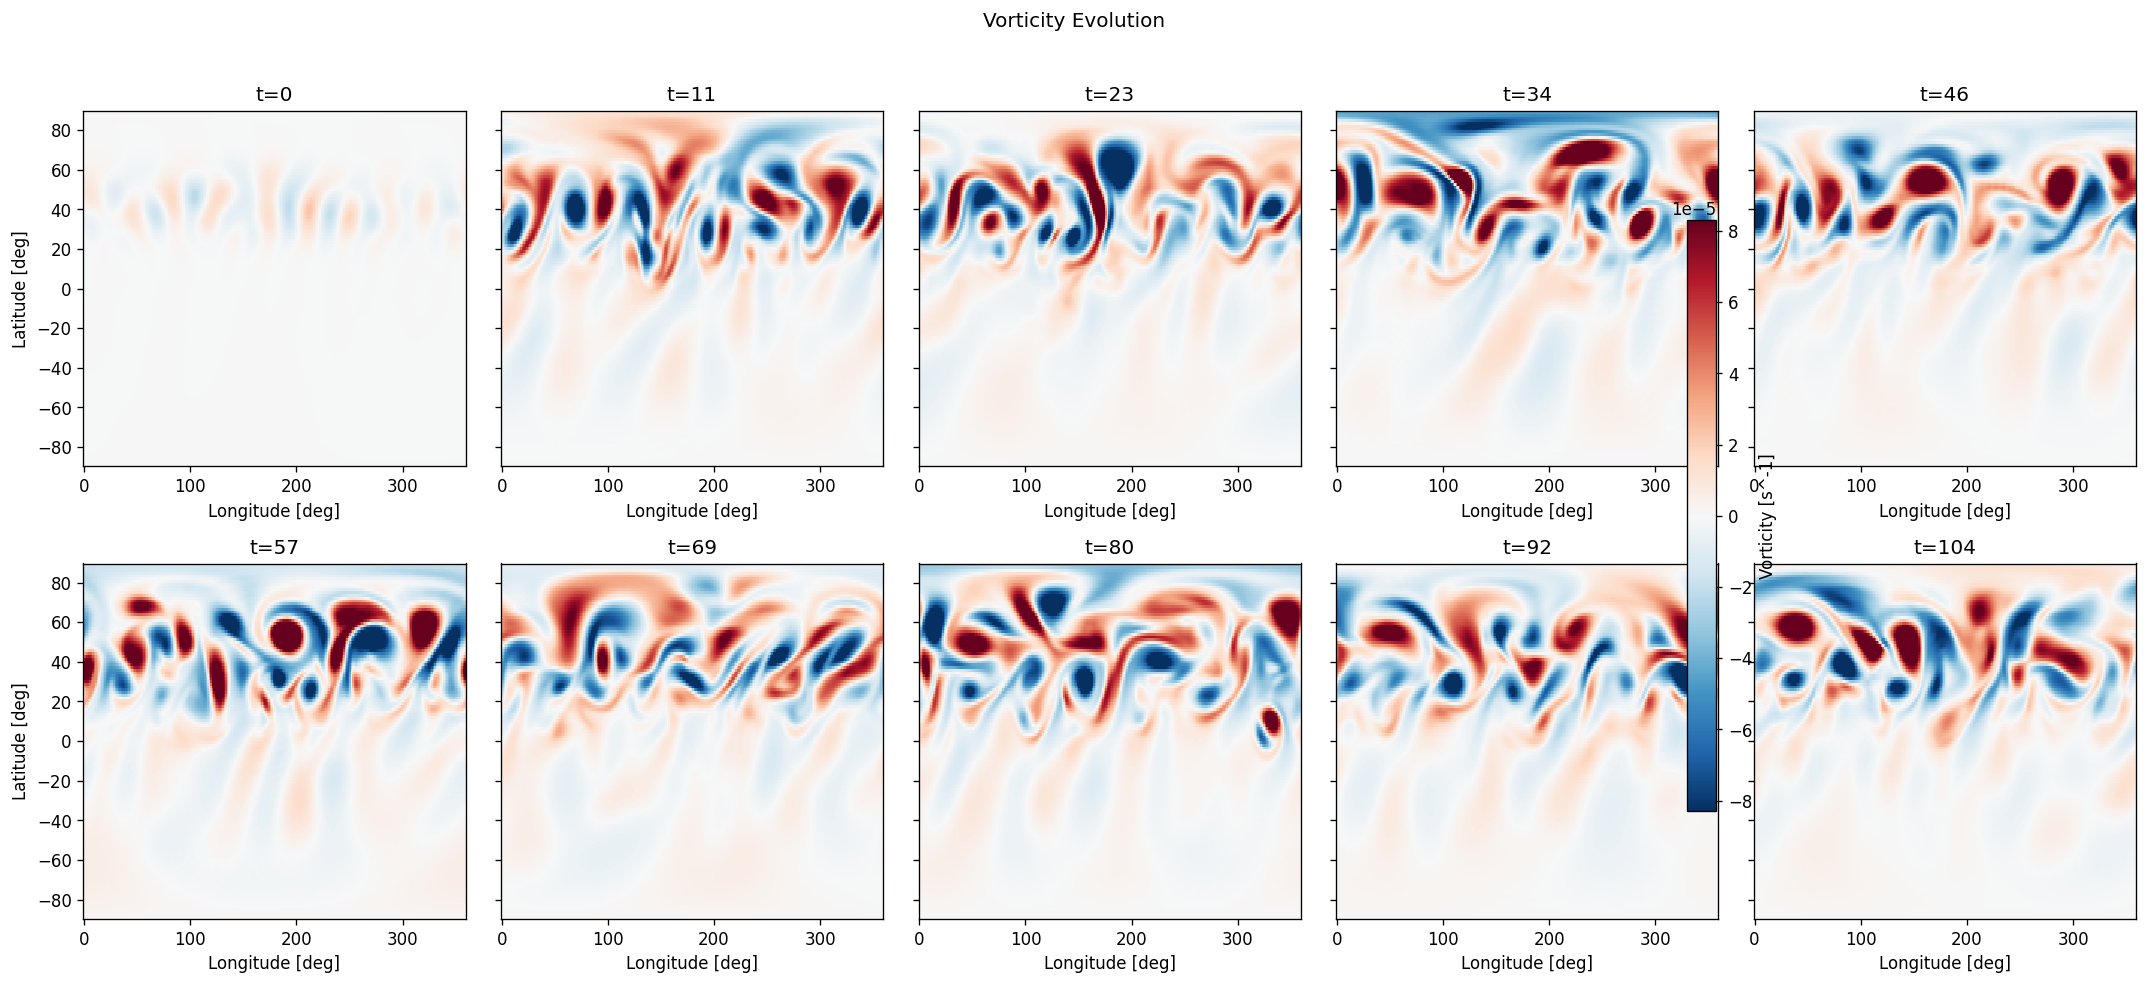

In [3]:
num_snaps = 10
total = len(ds.time)
indices = np.linspace(0, total - 1, num_snaps).astype(int)

vor = ds.vor.values
vlim = np.percentile(np.abs(vor), 98)

ncols = 5
nrows = int(np.ceil(num_snaps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows), sharey=True)
for i, idx in enumerate(indices):
    ax = axes.flat[i]
    im = ax.pcolormesh(lon, lat, vor[idx], cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
    ax.set_title(f"t={idx}")
    ax.set_xlabel("Longitude [deg]")
    if i % ncols == 0:
        ax.set_ylabel("Latitude [deg]")
for j in range(num_snaps, nrows * ncols):
    axes.flat[j].set_visible(False)
fig.colorbar(im, ax=axes, label="Vorticity [s^-1]", shrink=0.8)
fig.suptitle("Vorticity Evolution", y=1.02)
plt.tight_layout()
plt.show()

---
## 1.2 Streamfunction

The streamfunction $\psi$ at a single snapshot. In 2D incompressible flow, streamlines
are contours of $\psi$ and the flow is tangent to them everywhere.

Black contour lines = streamlines (iso-$\psi$ curves).
Tightly packed contours = strong flow (jets). Closed contours = vortices.

**What to look for:**
- Closed contours around vorticity centers
- Tight contour packing near jet latitude
- Large-scale wave patterns

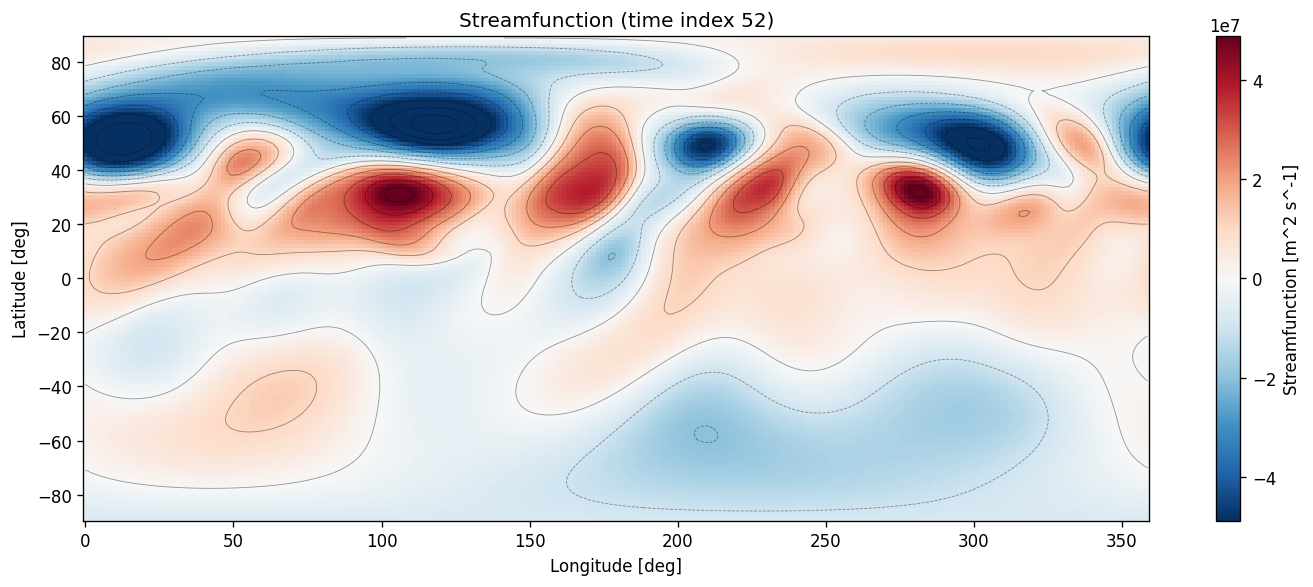

In [4]:
t_idx = len(ds.time) // 2
psi = ds.stream.isel(time=t_idx).values

fig, ax = plt.subplots(figsize=(12, 5))
vlim = np.percentile(np.abs(psi), 98)
im = ax.pcolormesh(lon, lat, psi, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="Streamfunction [m^2 s^-1]")
ax.contour(lon, lat, psi, levels=15, colors="k", linewidths=0.5, alpha=0.4)
ax.set_title(f"Streamfunction (time index {t_idx})")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.show()

---
## 1.3 Zonal Mean Zonal Wind

Zonal mean (longitude-averaged) zonal wind $[u](\phi)$ as a function of latitude,
plotted for every time step. Each line is one snapshot, colored by time.

In the barotropic vorticity equation, eddy momentum fluxes drive changes in the
zonal mean flow. Spread between lines shows how eddies accelerate or decelerate the jet.

**What to look for:**
- Jet peak latitude and strength
- Time evolution: is the jet accelerating, shifting, or oscillating?
- Equatorial flow should be weak

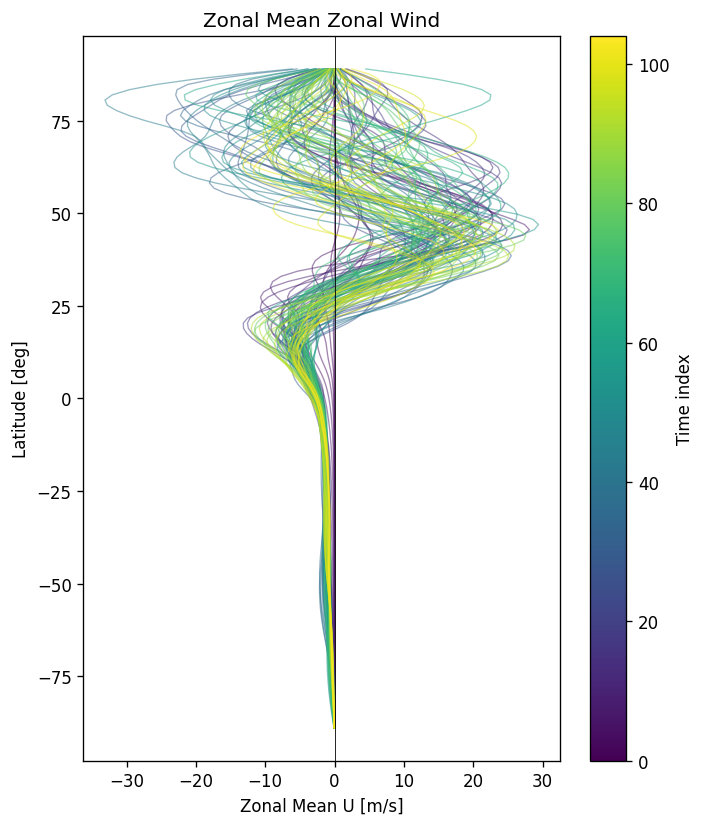

In [5]:
u = ds.ucomp.values
ntime = u.shape[0]
u_zonal = u.mean(axis=2)

fig, ax = plt.subplots(figsize=(6, 7))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, ntime))
for t in range(ntime):
    ax.plot(u_zonal[t], lat, color=colors[t], alpha=0.5, linewidth=0.8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, ntime - 1))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Time index")
ax.axvline(0, color="k", linewidth=0.5)
ax.set_xlabel("Zonal Mean U [m/s]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Zonal Mean Zonal Wind")
plt.tight_layout()
plt.show()

---
## 1.4 Hovmoller Diagram (Meridional Wind)

Time-longitude cross section of meridional wind $v$ at the jet latitude ($\approx 45^\circ$N).
Since the zonal mean of $v$ is near zero, any signal in $v$ is direct wave activity,
making it a cleaner indicator of Rossby wave propagation than vorticity.

Diagonal bands sloping right = eastward propagation; left = westward.
The slope gives the phase speed. Vertical bands = stationary waves.

**What to look for:**
- Band slope = propagation speed and direction
- Band spacing = dominant wavelength
- Disruptions = wave breaking or blocking events

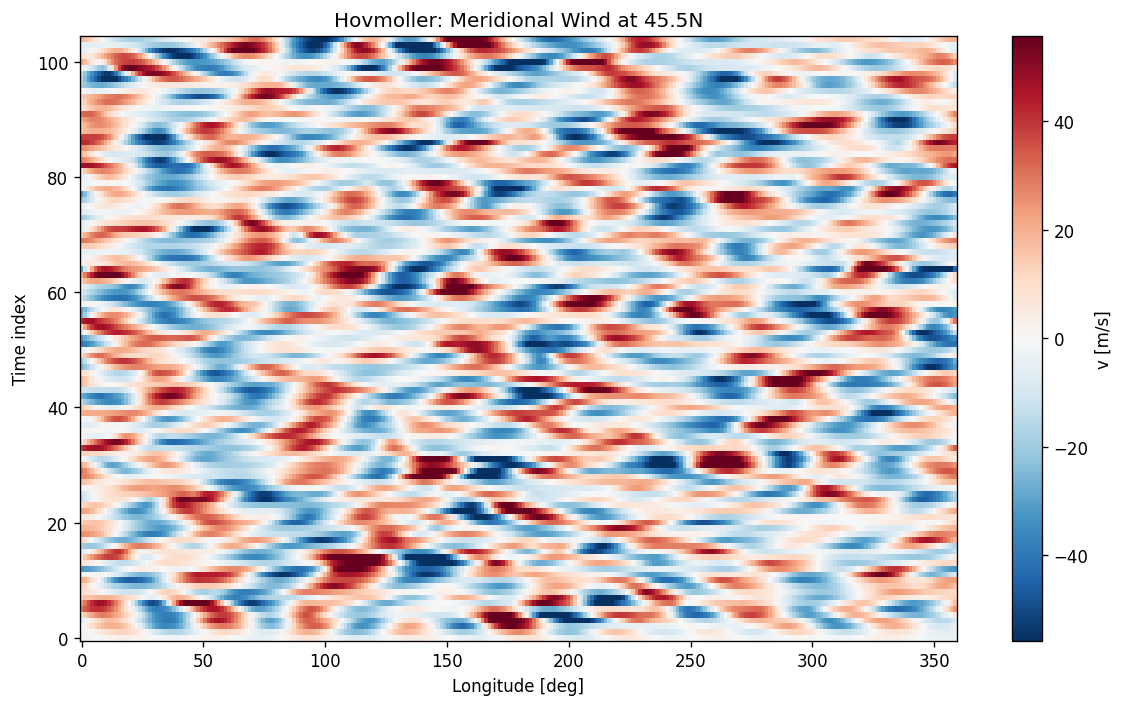

In [6]:
target_lat = 45.0
lat_idx = np.argmin(np.abs(lat - target_lat))
v = ds.vcomp.values
v_at_lat = v[:, lat_idx, :]

time_indices = np.arange(len(ds.time))
vlim = np.percentile(np.abs(v_at_lat), 98)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(lon, time_indices, v_at_lat, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="v [m/s]")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Time index")
ax.set_title(f"Hovmoller: Meridional Wind at {lat[lat_idx]:.1f}N")
plt.tight_layout()
plt.show()

---
## 1.5 Enstrophy Time Series

Area-weighted global enstrophy $\mathcal{E} = \langle \frac{1}{2} \zeta^2 \rangle$
as a function of time, normalized by the initial value.

In the inviscid unforced BVE, enstrophy is exactly conserved. Here, the simulation
has external stirring and dissipation, so enstrophy varies in time. The time series
shows the balance between forcing (injection) and dissipation (removal).

**What to look for:**
- Oscillations reflect the forced-dissipative balance
- Secular trends indicate drift in the forcing/dissipation equilibrium
- Sudden spikes could indicate numerical issues

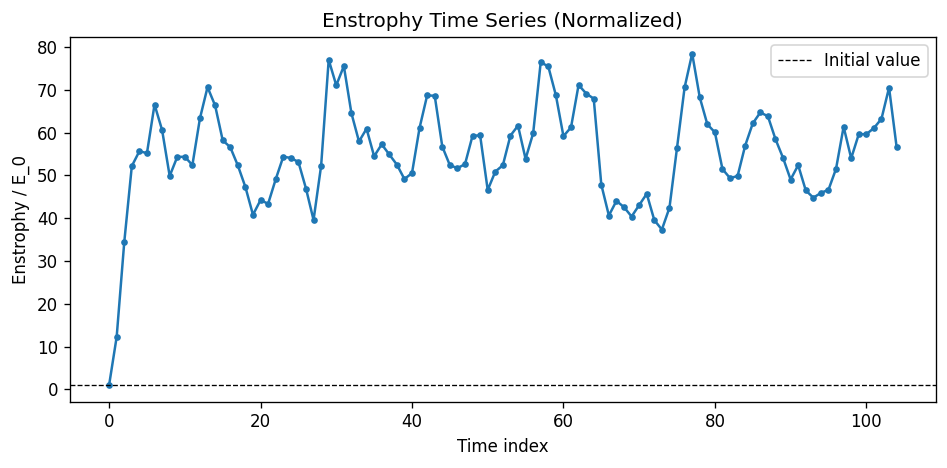

In [7]:
vor = ds.vor.values
ntime = vor.shape[0]
enstrophy = np.array([area_mean(0.5 * vor[t] ** 2) for t in range(ntime)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(ntime), enstrophy / enstrophy[0], marker="o", markersize=3)
ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8, label="Initial value")
ax.set_xlabel("Time index")
ax.set_ylabel("Enstrophy / E_0")
ax.set_title("Enstrophy Time Series (Normalized)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 1.6 Rossby Wave Diagnostics

Rossby waves are planetary-scale waves that propagate along the jet due to the
gradient of potential vorticity. In the raw fields they are masked by small-scale
turbulent eddies. To isolate them, we spectrally filter the meridional wind $v$
in the zonal direction, keeping only low wavenumbers.

**Filtered Hovmoller (top row):** Each panel shows a single zonal wavenumber of $v$
at the jet latitude. Diagonal bands = propagating waves. The slope gives the phase
speed: rightward tilt = eastward propagation (waves advected by the mean flow faster
than their intrinsic westward Rossby phase speed).

**Planetary vs synoptic (bottom left/center):** Grouped wavenumber bands.
$k = 1$-$4$ = planetary scale, $k = 4$-$8$ = synoptic scale.

**Eddy streamfunction (bottom right):** The streamfunction with its zonal mean removed,
$\psi' = \psi - [\psi]$. Shows the spatial wave train pattern at a single snapshot.

**What to look for:**
- Coherent diagonal bands in the Hovmoller panels = propagating Rossby waves
- Band tilt direction = propagation direction
- Consistent slope across wavenumbers = single dominant phase speed
- Wave train pattern in the eddy streamfunction alternating positive/negative lobes

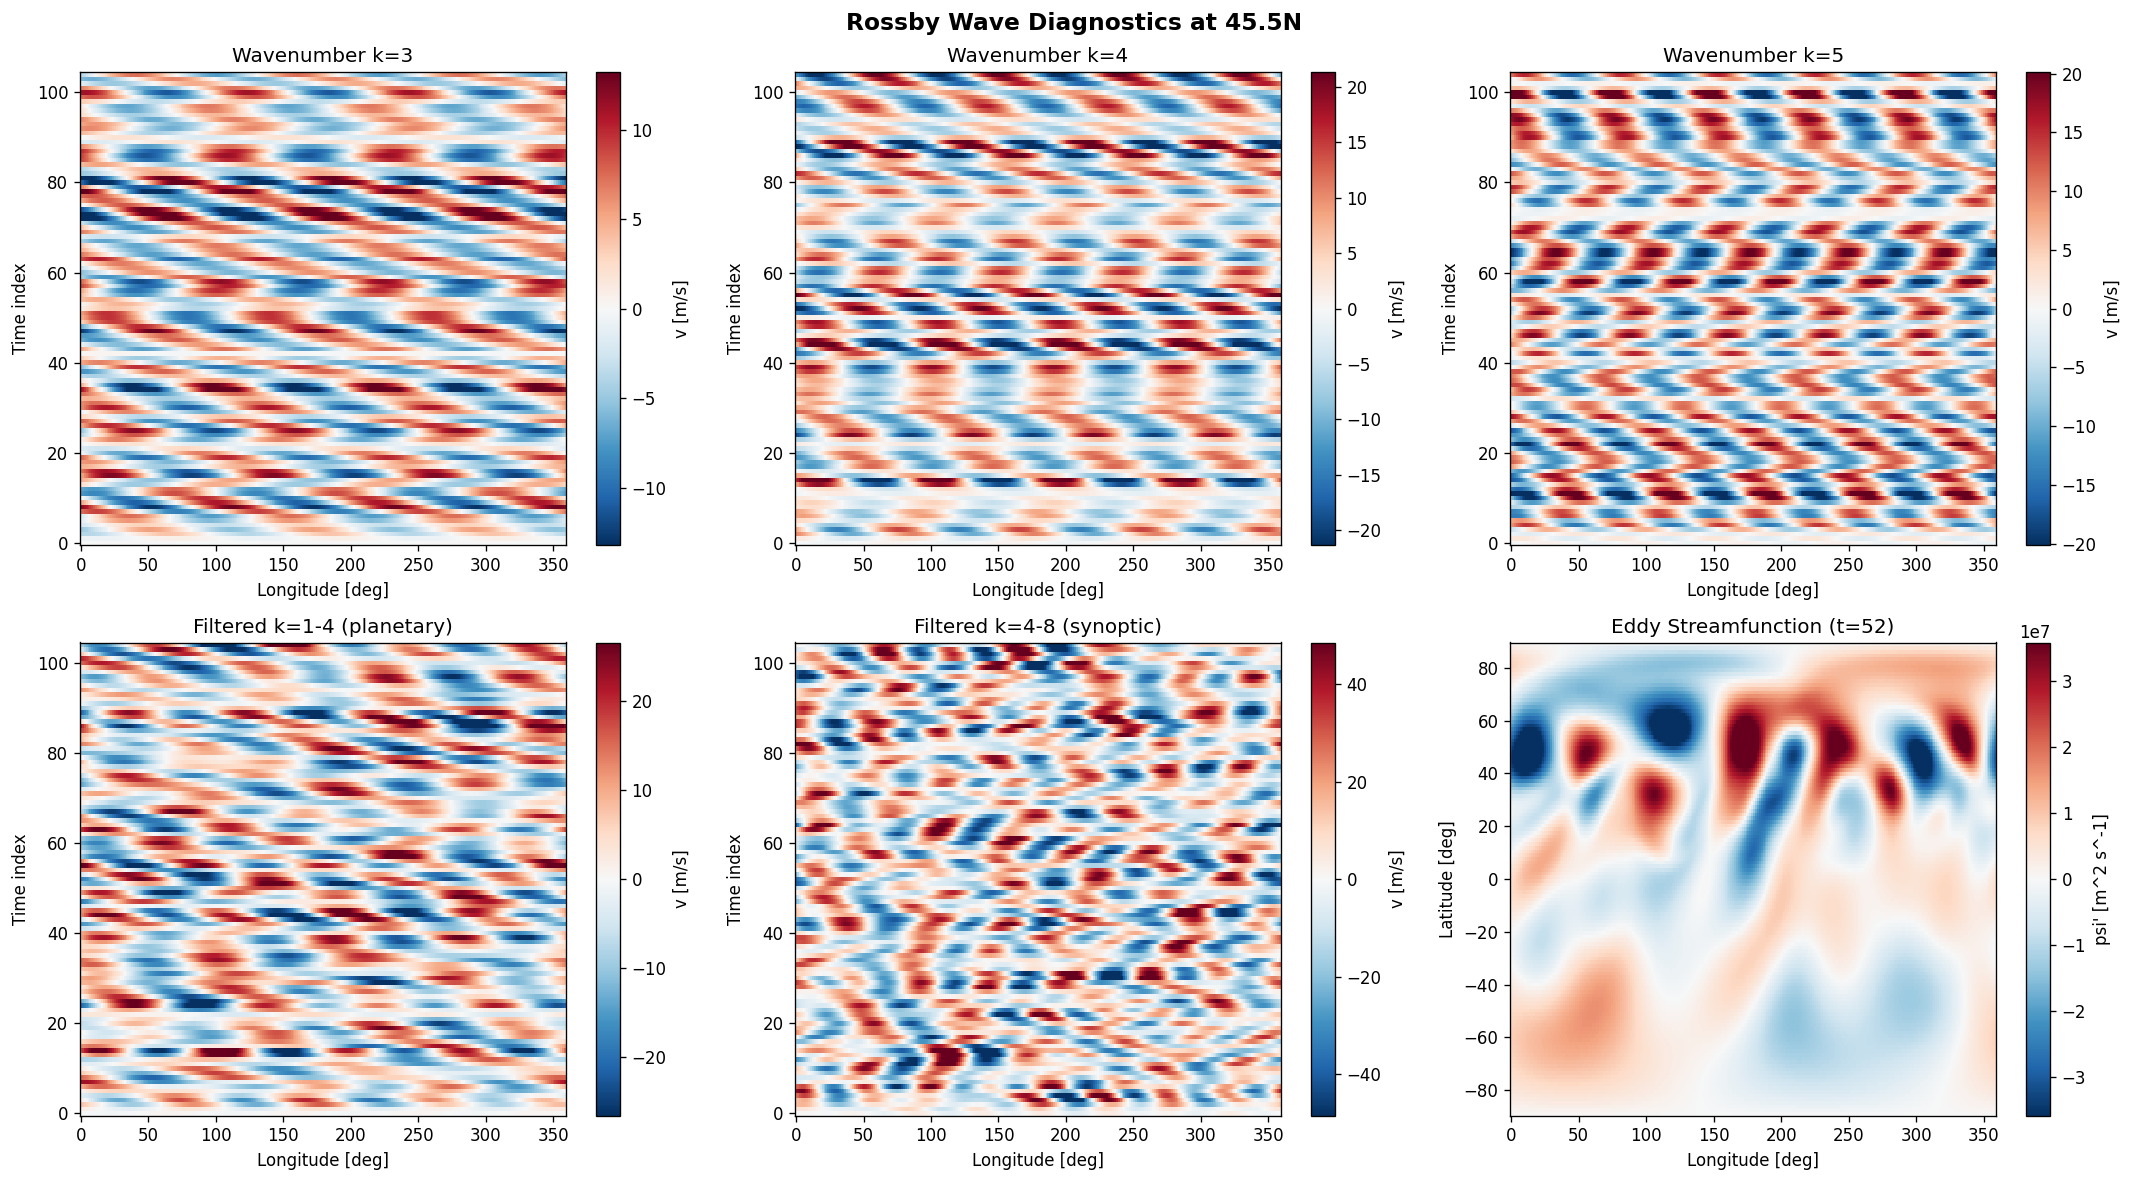

In [8]:
target_lat = 45.0
lat_idx = np.argmin(np.abs(lat - target_lat))
v_at_lat = ds.vcomp.values[:, lat_idx, :]  # (time, lon)
v_hat = np.fft.rfft(v_at_lat, axis=1)
ntime_steps = len(ds.time)
time_ax = np.arange(ntime_steps)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: individual wavenumber Hovmollers
for i, k_show in enumerate([3, 4, 5]):
    ax = axes[0, i]
    v_hat_k = np.zeros_like(v_hat)
    v_hat_k[:, k_show] = v_hat[:, k_show]
    v_k = np.fft.irfft(v_hat_k, n=v_at_lat.shape[1], axis=1)
    vlim = np.percentile(np.abs(v_k), 98)
    im = ax.pcolormesh(lon, time_ax, v_k, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
    fig.colorbar(im, ax=ax, label="v [m/s]")
    ax.set_title(f"Wavenumber k={k_show}")
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Time index")

# Bottom left: planetary scale k=1-4
ax = axes[1, 0]
v_hat_filt = np.zeros_like(v_hat)
v_hat_filt[:, 1:5] = v_hat[:, 1:5]
v_filt = np.fft.irfft(v_hat_filt, n=v_at_lat.shape[1], axis=1)
vlim = np.percentile(np.abs(v_filt), 98)
im = ax.pcolormesh(lon, time_ax, v_filt, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="v [m/s]")
ax.set_title("Filtered k=1-4 (planetary)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Time index")

# Bottom center: synoptic scale k=4-8
ax = axes[1, 1]
v_hat_filt2 = np.zeros_like(v_hat)
v_hat_filt2[:, 4:9] = v_hat[:, 4:9]
v_filt2 = np.fft.irfft(v_hat_filt2, n=v_at_lat.shape[1], axis=1)
vlim = np.percentile(np.abs(v_filt2), 98)
im = ax.pcolormesh(lon, time_ax, v_filt2, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="v [m/s]")
ax.set_title("Filtered k=4-8 (synoptic)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Time index")

# Bottom right: eddy streamfunction
ax = axes[1, 2]
t_mid = ntime_steps // 2
psi_snap = ds.stream.isel(time=t_mid).values
psi_eddy = psi_snap - psi_snap.mean(axis=1, keepdims=True)
vlim = np.percentile(np.abs(psi_eddy), 98)
im = ax.pcolormesh(lon, lat, psi_eddy, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="psi' [m^2 s^-1]")
ax.set_title(f"Eddy Streamfunction (t={t_mid})")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")

fig.suptitle(f"Rossby Wave Diagnostics at {lat[lat_idx]:.1f}N", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
# Part 2: General Fluid Diagnostics

These techniques apply to any fluid system with a velocity field.

## 2.1 Wind Quiver Plot

Velocity field as arrows overlaid on a vorticity color map.
Arrow direction = wind direction, arrow length = wind speed.
Arrows plotted every 4th grid point, clipped to $\pm 70^\circ$ latitude
(the $1/\cos\phi$ factor diverges at poles, producing misleading arrow lengths).

**What to look for:**
- Arrows circulating around vorticity centers (cyclonic = counterclockwise in NH)
- Jet regions: strong, aligned arrows
- Cross-contour flow: indicates ageostrophic motion

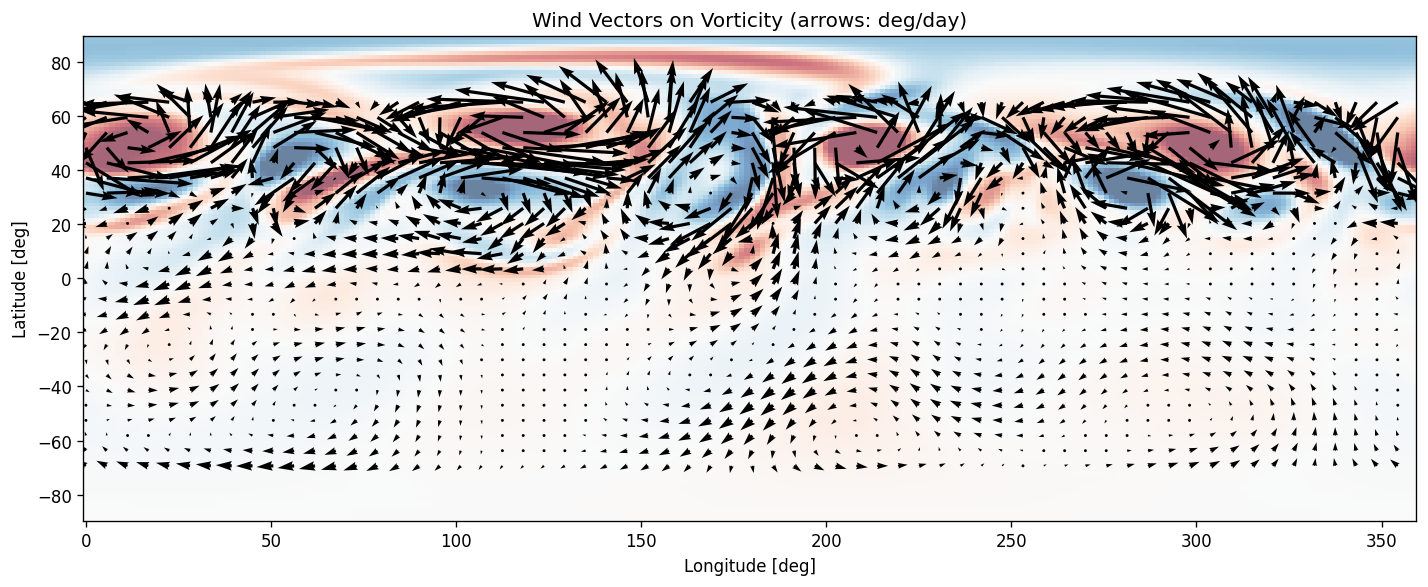

In [9]:
t_idx = len(ds.time) // 2
u_snap = ds.ucomp.isel(time=t_idx).values
v_snap = ds.vcomp.isel(time=t_idx).values
vor_snap = ds.vor.isel(time=t_idx).values

vlim = np.percentile(np.abs(vor_snap), 98)
skip = 4
lat_mask = np.abs(lat) <= 70.0
lat_q = lat[lat_mask]

DEG_PER_M = 180.0 / (np.pi * EARTH_RADIUS)
SECS_PER_DAY = 86400.0
LAT_2D = np.deg2rad(lat)[:, None] * np.ones((1, len(lon)))
cos_lat_2d = np.cos(LAT_2D).clip(1e-6)
u_deg = u_snap * DEG_PER_M / cos_lat_2d * SECS_PER_DAY
v_deg = v_snap * DEG_PER_M * SECS_PER_DAY

fig, ax = plt.subplots(figsize=(12, 5))
ax.pcolormesh(lon, lat, vor_snap, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto", alpha=0.6)
ax.quiver(
    lon[::skip], lat_q[::skip],
    u_deg[lat_mask, :][::skip, ::skip],
    v_deg[lat_mask, :][::skip, ::skip],
)
ax.set_title("Wind Vectors on Vorticity (arrows: deg/day)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.show()

---
## 2.2 Kinetic Energy Spectrum

Area-weighted zonal kinetic energy spectrum $E(k)$ on log-log axes.
Dashed line = $k^{-3}$ reference (expected for 2D geostrophic turbulence enstrophy cascade).

**What to look for:**
- Does the spectrum follow $k^{-3}$ over a range of wavenumbers?
- Sharp drop-off at high $k$: spectral taper or dissipation
- Pile-up at highest $k$: aliasing or insufficient resolution
- Steeper than $k^{-3}$: excessive dissipation

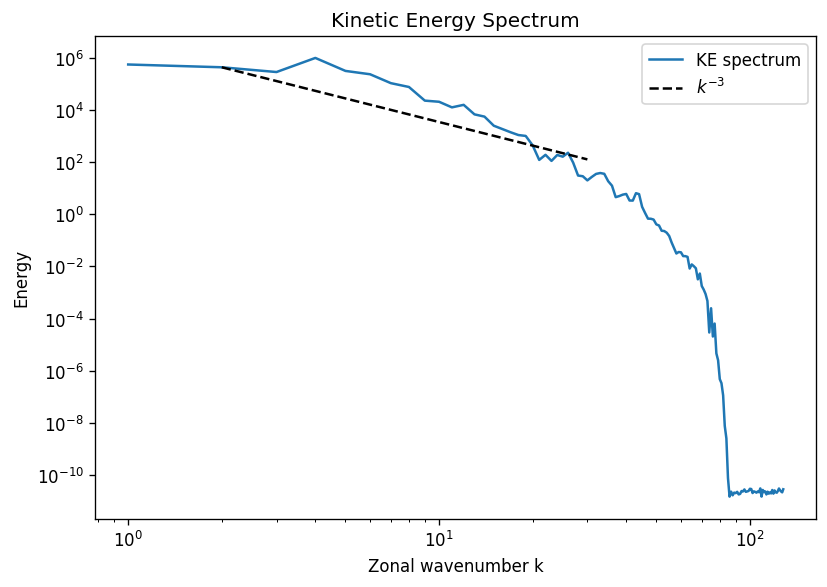

In [10]:
t_idx = len(ds.time) // 2
u_snap = ds.ucomp.isel(time=t_idx).values

u_hat = np.fft.rfft(u_snap, axis=1)
power = (np.abs(u_hat) ** 2) * cos_weights[:, None]
E_k = power.sum(axis=0) / cos_weights.sum()
k = np.arange(len(E_k))
k[0] = 1

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(k[1:], E_k[1:], label="KE spectrum")
k_ref = np.array([2, 30])
ax.loglog(k_ref, E_k[2] * (k_ref / 2.0) ** (-3), "k--", label="$k^{-3}$")
ax.set_xlabel("Zonal wavenumber k")
ax.set_ylabel("Energy")
ax.set_title("Kinetic Energy Spectrum")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2.3 Kinetic Energy Time Series

Area-weighted global kinetic energy $KE = \langle \frac{1}{2} u^2 \rangle$ normalized
by its initial value. Like enstrophy (1.5), KE varies in this forced-dissipative system.

KE is dominated by large scales while enstrophy by small scales.
Comparing both tells you which scales are gaining or losing energy.

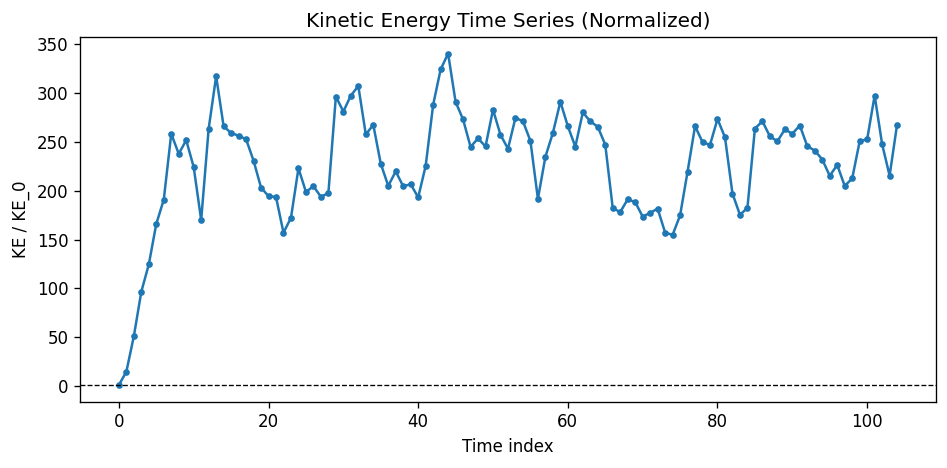

In [11]:
u = ds.ucomp.values
ntime = u.shape[0]
ke = np.array([area_mean(0.5 * u[t] ** 2) for t in range(ntime)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(ntime), ke / ke[0], marker="o", markersize=3)
ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8)
ax.set_xlabel("Time index")
ax.set_ylabel("KE / KE_0")
ax.set_title("Kinetic Energy Time Series (Normalized)")
plt.tight_layout()
plt.show()

---
## 2.4 Jet Stream Structure (Time-Mean Zonal Wind)

To see jet streams clearly, plot the zonal wind $u$ averaged over time.
Time-averaging removes transient eddies, leaving only the persistent mean circulation.

**Left panel:** Lat-lon map of $\overline{u}$ (time mean). The jet stream appears as
a strong band of eastward (positive) wind.

**Right panel:** Zonal + time mean $[\overline{u}](\phi)$ profile. Red shading = eastward,
blue = westward. Peak location and magnitude define the jet.

**What to look for:**
- Jet latitude and width
- Longitudinal variations in jet strength (stationary waves)
- Asymmetry between hemispheres

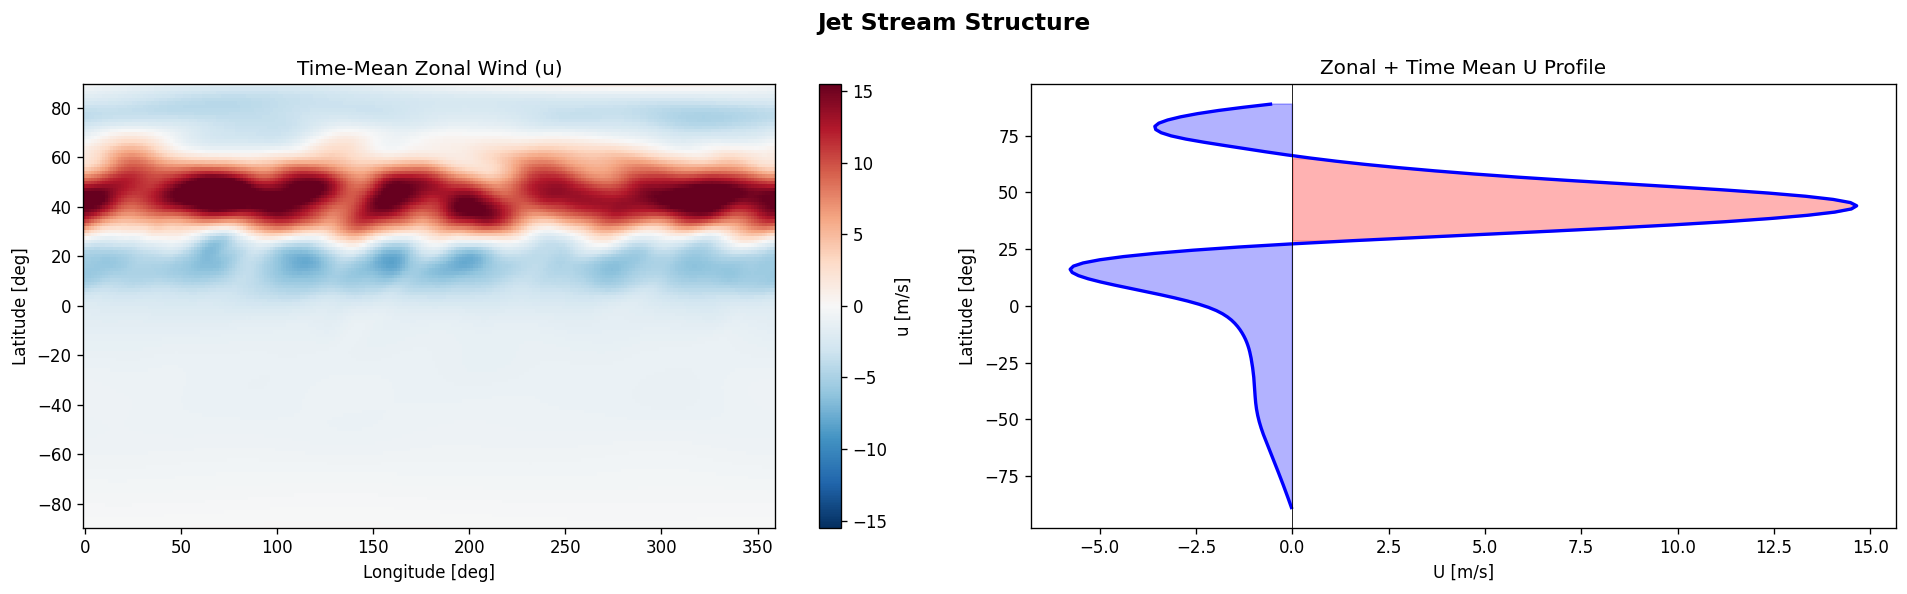

In [12]:
u_mean = ds.ucomp.mean(dim="time").values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Lat-lon map
ax = axes[0]
vlim = np.percentile(np.abs(u_mean), 98)
im = ax.pcolormesh(lon, lat, u_mean, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="u [m/s]")
ax.set_title("Time-Mean Zonal Wind (u)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")

# Panel 2: Zonal + time mean profile
ax = axes[1]
u_profile = u_mean.mean(axis=1)
ax.plot(u_profile, lat, "b-", linewidth=2)
ax.axvline(0, color="k", linewidth=0.5)
ax.fill_betweenx(lat, 0, u_profile, where=u_profile > 0, alpha=0.3, color="red")
ax.fill_betweenx(lat, 0, u_profile, where=u_profile < 0, alpha=0.3, color="blue")
ax.set_xlabel("U [m/s]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Zonal + Time Mean U Profile")

fig.suptitle("Jet Stream Structure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2.5 Wind Speed and Direction

Wind speed as background color (magma colormap) with normalized direction arrows overlaid.
All arrows have the same length -- magnitude is shown only by the background color.
Useful for seeing flow patterns without arrow length distortion.

**What to look for:**
- Rotation around vortex centers
- Speed maxima along the jet
- Meridional excursions indicating wave breaking

/var/folders/4p/1s3ml81d7sx9zjdx06ttqs8r0000gp/T/ipykernel_51357/2083028470.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


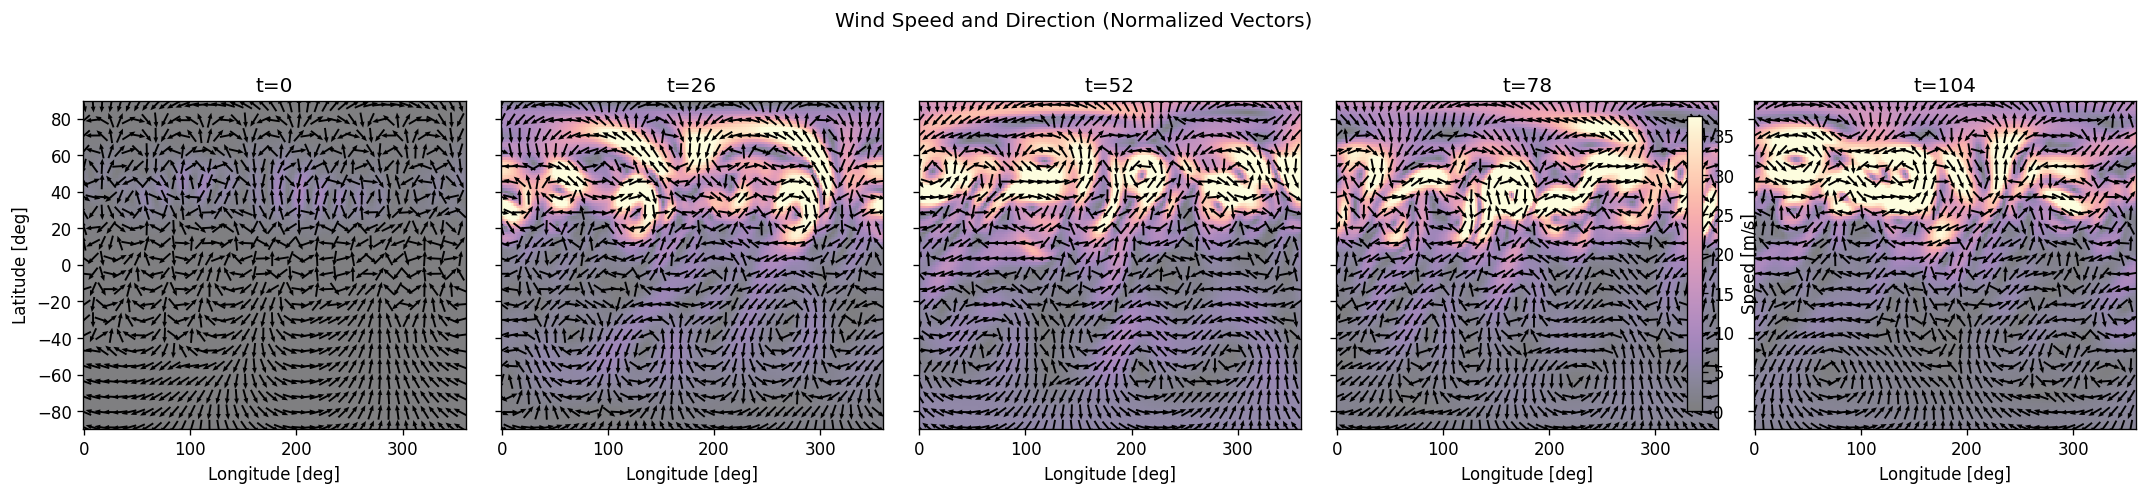

In [13]:
num_snaps = 5
total = len(ds.time)
indices = np.linspace(0, total - 1, num_snaps).astype(int)
subsample = 6

fig, axes = plt.subplots(1, num_snaps, figsize=(18, 4), sharey=True)

speed_all = np.sqrt(ds.ucomp.values ** 2 + ds.vcomp.values ** 2)
vmax_color = np.percentile(speed_all, 95)

for i, idx in enumerate(indices):
    ax = axes[i]
    u_snap = ds.ucomp.isel(time=idx).values
    v_snap = ds.vcomp.isel(time=idx).values
    s = np.sqrt(u_snap ** 2 + v_snap ** 2)

    im = ax.pcolormesh(lon, lat, s, cmap="magma", vmin=0, vmax=vmax_color, shading="auto", alpha=0.5)

    skip = (slice(None, None, subsample), slice(None, None, subsample))
    u_norm = u_snap[skip] / (s[skip] + 1e-10)
    v_norm = v_snap[skip] / (s[skip] + 1e-10)
    ax.quiver(
        lon[skip[1]], lat[skip[0]], u_norm, v_norm,
        color="black", scale=25, pivot="middle", width=0.005,
        headwidth=2.5, headlength=3, headaxislength=3,
    )
    ax.set_title(f"t={idx}")
    ax.set_xlabel("Longitude [deg]")
    if i == 0:
        ax.set_ylabel("Latitude [deg]")

fig.colorbar(im, ax=axes, label="Speed [m/s]", shrink=0.8)
fig.suptitle("Wind Speed and Direction (Normalized Vectors)", y=1.02)
plt.tight_layout()
plt.show()

---
# Part 3: Globe Projections (Cartopy)

Orthographic projections show the data on a sphere, giving a more intuitive
sense of spatial scale and polar geometry than flat lat-lon maps.
Requires `cartopy`.

In [14]:
import cartopy.crs as ccrs

## 3.1 Vorticity on the Globe

Four orthographic views of the vorticity field at a single snapshot:
North Pole, South Pole, and two mid-latitude views from opposite sides.

This is the same data as 1.1 but projected onto a sphere, which reveals
the true spatial extent of eddies and avoids the area distortion of
equirectangular (flat lat-lon) maps near the poles.

**What to look for:**
- Eddy activity concentrated in the NH stirring region
- Quiet SH (no forcing there)
- True spatial scale of vortices relative to the globe

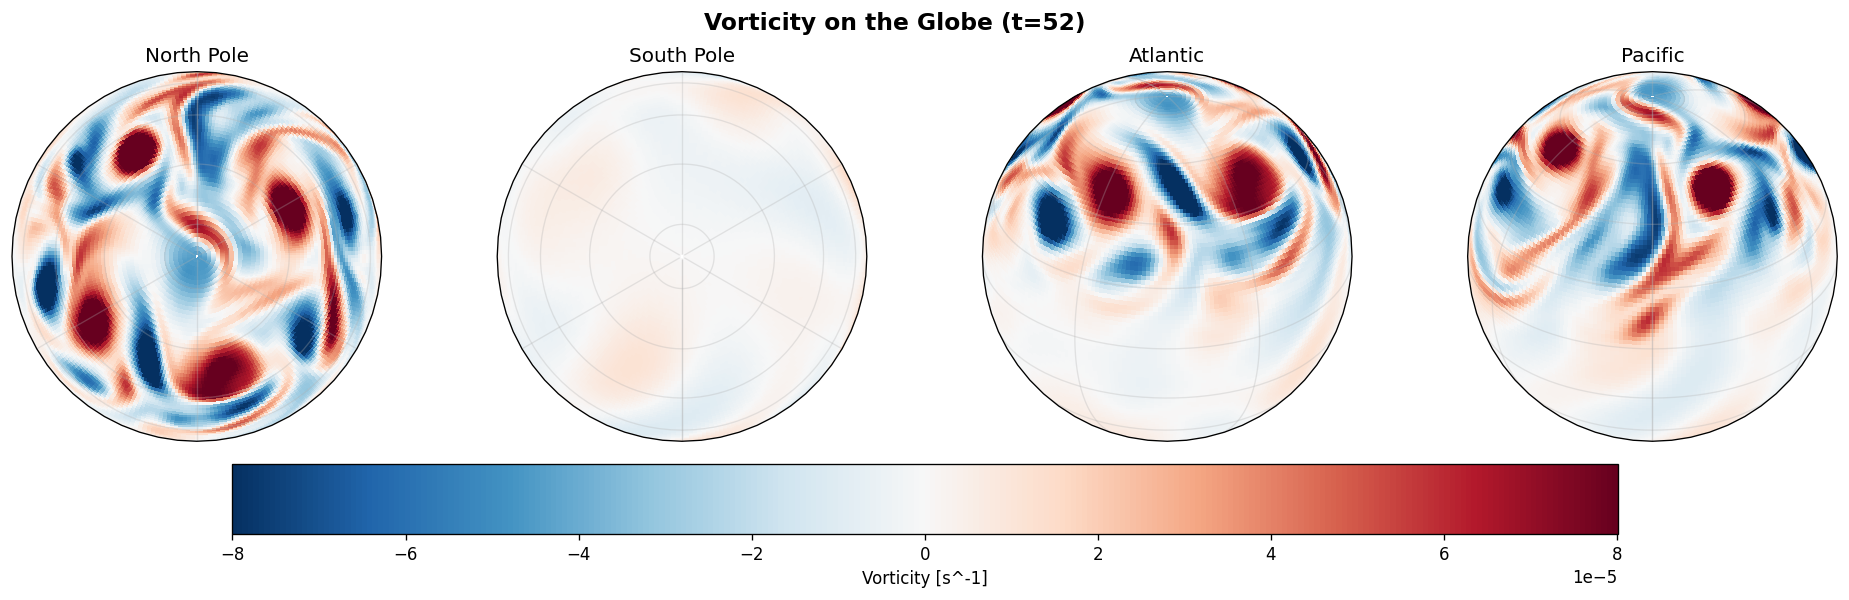

In [15]:
pc = ccrs.PlateCarree()

t_idx = len(ds.time) // 2
vor_snap = ds.vor.isel(time=t_idx).values
vlim = np.percentile(np.abs(vor_snap), 98)

views = [
    ("North Pole", ccrs.Orthographic(0, 90)),
    ("South Pole", ccrs.Orthographic(0, -90)),
    ("Atlantic", ccrs.Orthographic(-30, 30)),
    ("Pacific", ccrs.Orthographic(180, 30)),
]

fig = plt.figure(figsize=(20, 5))
ax_list = []
for i, (title, proj) in enumerate(views):
    ax = fig.add_subplot(1, 4, i + 1, projection=proj)
    im = ax.pcolormesh(lon, lat, vor_snap, cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       shading="auto", transform=pc)
    ax.set_global()
    ax.gridlines(alpha=0.3)
    ax.set_title(title)
    ax_list.append(ax)

fig.colorbar(im, ax=ax_list, label="Vorticity [s^-1]", shrink=0.8,
             orientation="horizontal", pad=0.05)
fig.suptitle(f"Vorticity on the Globe (t={t_idx})", fontsize=14, fontweight="bold")
plt.show()

---
## 3.2 Multi-Field Globe Comparison

Three fields on the same globe view side by side: wind speed, time-mean zonal wind
(jet stream), and streamfunction. Comparing them on the same projection makes it
easy to see how the jet, eddies, and large-scale circulation relate spatially.

**What to look for:**
- Wind speed maxima along the jet band
- Jet stream as a continuous ring around the globe
- Streamfunction gyres embedded in the jet

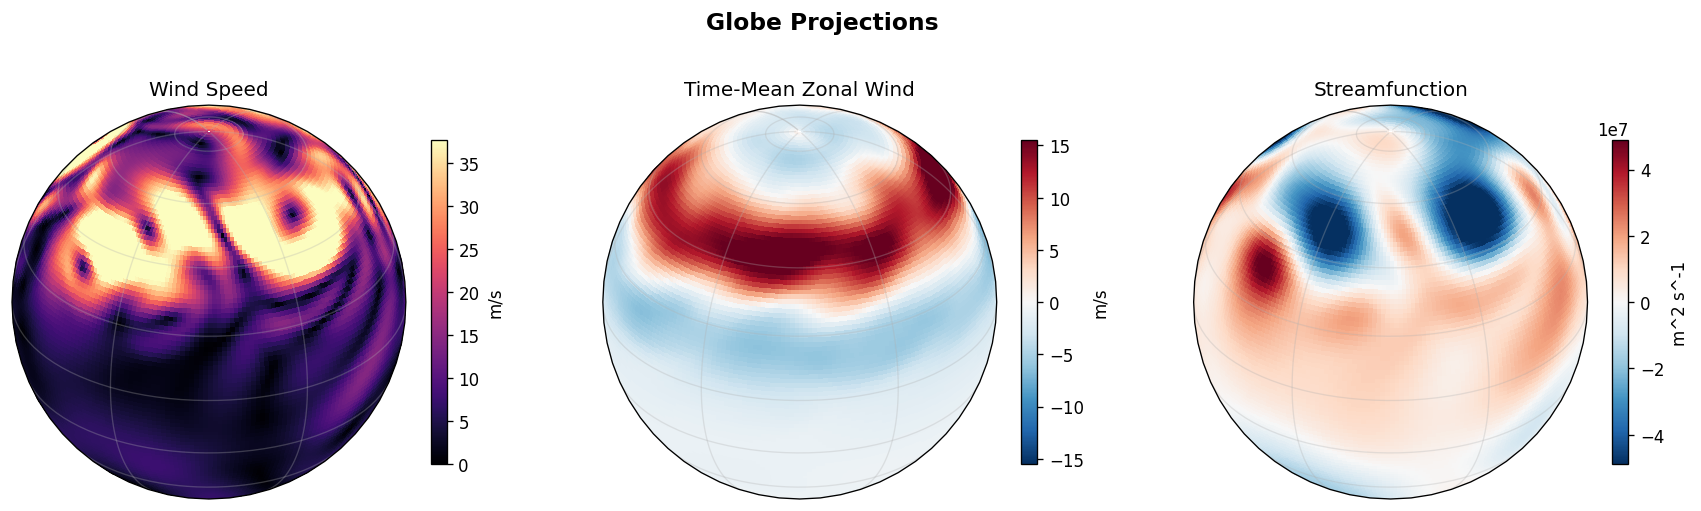

In [16]:
t_idx = len(ds.time) // 2
proj = ccrs.Orthographic(-30, 30)

fields = [
    ("Wind Speed", np.sqrt(ds.ucomp.isel(time=t_idx).values ** 2 +
                           ds.vcomp.isel(time=t_idx).values ** 2),
     "magma", None, "m/s"),
    ("Time-Mean Zonal Wind", ds.ucomp.mean(dim="time").values,
     "RdBu_r", "symmetric", "m/s"),
    ("Streamfunction", ds.stream.isel(time=t_idx).values,
     "RdBu_r", "symmetric", "m^2 s^-1"),
]

fig = plt.figure(figsize=(18, 5))
for i, (title, data, cmap, mode, units) in enumerate(fields):
    ax = fig.add_subplot(1, 3, i + 1, projection=proj)
    if mode == "symmetric":
        vlim = np.percentile(np.abs(data), 98)
        kwargs = {"vmin": -vlim, "vmax": vlim}
    else:
        kwargs = {"vmin": 0, "vmax": np.percentile(data, 95)}
    im = ax.pcolormesh(lon, lat, data, cmap=cmap, shading="auto", transform=pc, **kwargs)
    ax.set_global()
    ax.gridlines(alpha=0.3)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label=units, shrink=0.7)

fig.suptitle("Globe Projections", fontsize=14, fontweight="bold")
plt.show()

---
## 3.3 Vorticity Evolution on the Globe

Same as 1.1 but on an orthographic projection. Shows how eddies develop and
propagate on the sphere over time. Each panel is a different time step.

Particularly useful for seeing how eddies wrap around the globe and how
their true spatial extent compares to the planetary scale.

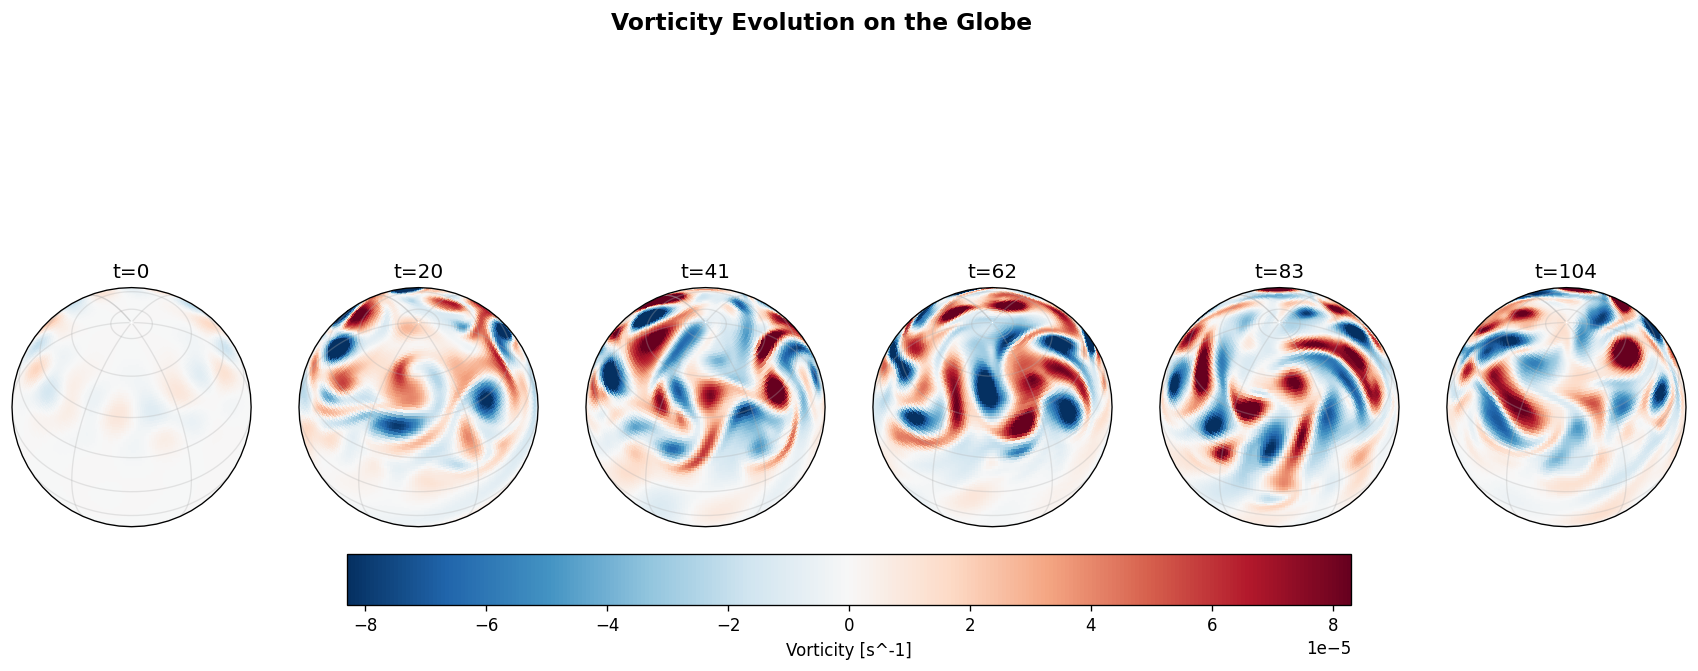

In [17]:
num_snaps = 6
total = len(ds.time)
indices = np.linspace(0, total - 1, num_snaps).astype(int)

vor_all = ds.vor.values
vlim = np.percentile(np.abs(vor_all), 98)
proj = ccrs.Orthographic(-30, 45)

fig = plt.figure(figsize=(18, 6))
ax_list = []
for i, idx in enumerate(indices):
    ax = fig.add_subplot(1, num_snaps, i + 1, projection=proj)
    im = ax.pcolormesh(lon, lat, vor_all[idx], cmap="RdBu_r", vmin=-vlim, vmax=vlim,
                       shading="auto", transform=pc)
    ax.set_global()
    ax.gridlines(alpha=0.3)
    ax.set_title(f"t={idx}")
    ax_list.append(ax)

fig.colorbar(im, ax=ax_list, label="Vorticity [s^-1]", shrink=0.6,
             orientation="horizontal", pad=0.05)
fig.suptitle("Vorticity Evolution on the Globe", fontsize=14, fontweight="bold")
plt.show()